In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("cleaned_data.csv", low_memory=False) 


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 46 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Seller_NTN                        20000 non-null  object 
 1   Seller_Name                       20000 non-null  object 
 2   Seller_S.T.Reg.No                 20000 non-null  object 
 3   Seller_Address                    20000 non-null  object 
 4   Customer_Receipt_NO               20000 non-null  int64  
 5   Customer_NTN                      20000 non-null  object 
 6   Customer_NAME                     20000 non-null  object 
 7   Customer_Tax_ID                   20000 non-null  object 
 8   Customer_Address                  20000 non-null  object 
 9   Customer_Business                 20000 non-null  object 
 10  Product 1                         20000 non-null  object 
 11  Product 2                         20000 non-null  object 
 12  Prod

In [4]:
# Merge product columns into one
df["All_Products"] = df[["Product 1", "Product 2", "Product 3", "Product 4"]].apply(lambda x: ', '.join(x.dropna().astype(str)), axis=1)

# Sum up quantities, prices, and tax amounts into single attributes
df["Total_Quantity"] = df[["Quantity_Product_1", "Quantity_Product_2", "Quantity_Product_3", "Quantity_Product_4"]].sum(axis=1)
df["Total_Price"] = df[["Amount Excluding Taxes_Product_1", "Amount Excluding Taxes_Product_2",
                        "Amount Excluding Taxes_Product_3", "Amount Excluding Taxes_Product_4"]].sum(axis=1)
df["Total_Tax"] = df[["Sales Tax @ 18%_Product_1", "Sales Tax @ 18%_Product_2",
                      "Sales Tax @ 18%_Product_3", "Sales Tax @ 18%_Product_4"]].sum(axis=1)

# Drop redundant columns
columns_to_drop = [col for col in df.columns if "Product" in col and col not in ["All_Products", "Total_Quantity", "Total_Price", "Total_Tax"]]
df.drop(columns=columns_to_drop, inplace=True)

# Display updated dataset structure
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Seller_NTN                    20000 non-null  object 
 1   Seller_Name                   20000 non-null  object 
 2   Seller_S.T.Reg.No             20000 non-null  object 
 3   Seller_Address                20000 non-null  object 
 4   Customer_Receipt_NO           20000 non-null  int64  
 5   Customer_NTN                  20000 non-null  object 
 6   Customer_NAME                 20000 non-null  object 
 7   Customer_Tax_ID               20000 non-null  object 
 8   Customer_Address              20000 non-null  object 
 9   Customer_Business             20000 non-null  object 
 10  Date                          20000 non-null  object 
 11  Total Amount Excluding Taxes  20000 non-null  int64  
 12  Total Sales Tax @ 18%         20000 non-null  float64
 13  T

(None,
     Seller_NTN             Seller_Name        Seller_S.T.Reg.No  \
 0  3.65029E+12  MUHAMMAD BEHZAD ARSHAD  10000-10046-8761-413-23   
 1   3.7405E+12       MISS FARHAT MALIK  10000-10046-8761-413-23   
 2  3.73012E+12      MIRZA SHAHBAZ BAIG  10000-10046-8761-413-23   
 3  3.65029E+12   MUHAMMAD BILAL ARSHAD  10000-10046-8761-413-23   
 4  3.65017E+12        BABAR HABIB NOON    10000-77-18730-413-23   
 
          Seller_Address  Customer_Receipt_NO Customer_NTN  \
 0  040-Tando Allah Main              1122916    0000092-2   
 1  118. Gulshan-E-Iqbal              1181647    0000094-9   
 2  131-West Wood Colony              1196218    0000098-1   
 3  145-C Sattelite Town               908244    0000131-7   
 4  14-Km Ferozpure Road               902983    0000146-5   
 
             Customer_NAME    Customer_Tax_ID      Customer_Address  \
 0             ABDUL MANAN  32-77-8761-413-23  145-C Sattelite Town   
 1         MUNAWAR SULTANA  33-77-8761-413-23  Wala Colony House 34

In [5]:
# Drop specified columns
columns_to_remove = ["Seller_Name", "Seller_Address", "Customer_NAME", "Customer_Address"]
df.drop(columns=columns_to_remove, inplace=True)

# Display updated dataset structure
df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Seller_NTN                    20000 non-null  object 
 1   Seller_S.T.Reg.No             20000 non-null  object 
 2   Customer_Receipt_NO           20000 non-null  int64  
 3   Customer_NTN                  20000 non-null  object 
 4   Customer_Tax_ID               20000 non-null  object 
 5   Customer_Business             20000 non-null  object 
 6   Date                          20000 non-null  object 
 7   Total Amount Excluding Taxes  20000 non-null  int64  
 8   Total Sales Tax @ 18%         20000 non-null  float64
 9   Total Amount Including Taxes  20000 non-null  float64
 10  All_Products                  20000 non-null  object 
 11  Total_Quantity                20000 non-null  int64  
 12  Total_Price                   20000 non-null  int64  
 13  T

(None,
     Seller_NTN        Seller_S.T.Reg.No  Customer_Receipt_NO Customer_NTN  \
 0  3.65029E+12  10000-10046-8761-413-23              1122916    0000092-2   
 1   3.7405E+12  10000-10046-8761-413-23              1181647    0000094-9   
 2  3.73012E+12  10000-10046-8761-413-23              1196218    0000098-1   
 3  3.65029E+12  10000-10046-8761-413-23               908244    0000131-7   
 4  3.65017E+12    10000-77-18730-413-23               902983    0000146-5   
 
      Customer_Tax_ID              Customer_Business        Date  \
 0  32-77-8761-413-23                1 CARAT FASHION  2020-05-12   
 1  33-77-8761-413-23              1 DOLLAR 2 DOLLAR  2018-02-24   
 2  34-77-8761-413-23  1 DOLLAR 2 DOLLAR,Ali Traders  2022-05-04   
 3  35-77-8761-413-23                  1 DOLLAR SHOP  2021-01-12   
 4  36-77-8761-413-23          1 Dollar Shoping Mall  2023-08-16   
 
    Total Amount Excluding Taxes  Total Sales Tax @ 18%  \
 0                         13195                2375.1

In [6]:
# Convert date column with corrected format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Automatically detects the correct format

# Check if any dates failed to convert
df['Date'].isna().sum()


0

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Convert date column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Encoding categorical variables
label_encoders = {}
categorical_cols = ['Seller_NTN', 'Seller_S.T.Reg.No', 'Customer_NTN', 'Customer_Tax_ID', 'Customer_Business', 'All_Products']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Selecting features and target
X = df.drop(columns=['Total Amount Including Taxes', 'Date'])  # Drop Date and Target variable
y = df['Total Amount Including Taxes']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1, max_depth=6)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

mae, rmse


(12.836635836181618, 18.541358939168255)

In [9]:
from sklearn.metrics import r2_score
# Select a smaller subset of the dataset (10,000 rows for faster training)
df_sample = df.sample(n=10000, random_state=42)

# Drop less relevant columns (keeping only the most important ones)
selected_features = ['Total_Quantity', 'Total_Price', 'Total_Tax', 'Seller_NTN', 'Customer_NTN', 'All_Products']
X_sample = df_sample[selected_features]
y_sample = df_sample['Total Amount Including Taxes']

# Encode categorical variables
label_encoders = {}
for col in ['Seller_NTN', 'Customer_NTN', 'All_Products']:
    le = LabelEncoder()
    X_sample[col] = le.fit_transform(X_sample[col])
    label_encoders[col] = le

# Split the reduced dataset
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Train XGBoost with reduced complexity
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=30,  # Reduced number of trees for faster training
    learning_rate=0.1,
    max_depth=4  # Lower depth to reduce complexity
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1215456815.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[col] = le.fit_transform(X_sample[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1215456815.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[col] = le.fit_transform(X_sample[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1215456815.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

(559.7477551293946, 608.3072643285224, 0.9866411483414929)

In [10]:
# Select an even smaller subset of the dataset (5,000 rows)
df_sample = df.sample(n=5000, random_state=42)

# Keep only the most important features
selected_features = ['Total_Quantity', 'Total_Price', 'Total_Tax', 'Seller_NTN', 'Customer_NTN', 'All_Products']
X_sample = df_sample[selected_features]
y_sample = df_sample['Total Amount Including Taxes']

# Encode categorical variables
for col in ['Seller_NTN', 'Customer_NTN', 'All_Products']:
    le = LabelEncoder()
    X_sample[col] = le.fit_transform(X_sample[col])

# Split the reduced dataset
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Train XGBoost with further reduced complexity
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=20,  # Further reducing the number of trees
    learning_rate=0.1,
    max_depth=3  # Lower depth to simplify the model
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

mae, rmse, r2



C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1063537312.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[col] = le.fit_transform(X_sample[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1063537312.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[col] = le.fit_transform(X_sample[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1063537312.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

(1615.7607186035154, 1780.1284339951749, 0.8889953403862537)

Mean Absolute Error (MAE): 1615.76

Root Mean Squared Error (RMSE): 1780.13

R² Score: 0.889 (~89% accuracy)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select a smaller subset of the dataset (10,000 rows for faster training)
df_sample = df.sample(n=10000, random_state=42)

# Keep only the most important features
selected_features = ['Total_Quantity', 'Total_Price', 'Total_Tax', 'Seller_NTN', 'Customer_NTN', 'All_Products']
X_sample = df_sample[selected_features]
y_sample = df_sample['Total Amount Including Taxes']

# Encode categorical variables
label_encoders = {}
for col in ['Seller_NTN', 'Customer_NTN', 'All_Products']:
    le = LabelEncoder()
    X_sample[col] = le.fit_transform(X_sample[col])
    label_encoders[col] = le

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Train a fresh Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = mse_lr ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr


C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\4084948747.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[col] = le.fit_transform(X_sample[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\4084948747.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_sample[col] = le.fit_transform(X_sample[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\4084948747.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

(2.004128418775508e-12, 2.382102803338685e-12, 1.0)

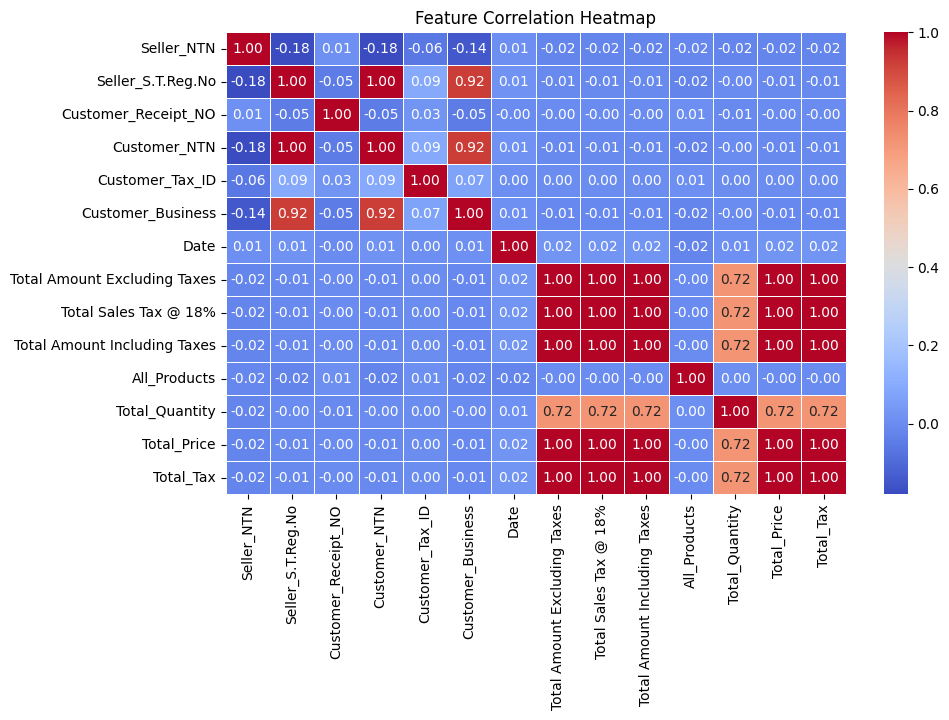

(                              Seller_NTN  Seller_S.T.Reg.No  \
 Seller_NTN                      1.000000          -0.179893   
 Seller_S.T.Reg.No              -0.179893           1.000000   
 Customer_Receipt_NO             0.009078          -0.050568   
 Customer_NTN                   -0.180245           0.999689   
 Customer_Tax_ID                -0.058315           0.094566   
 Customer_Business              -0.143999           0.922575   
 Date                            0.006370           0.014810   
 Total Amount Excluding Taxes   -0.020468          -0.005690   
 Total Sales Tax @ 18%          -0.020468          -0.005690   
 Total Amount Including Taxes   -0.020468          -0.005690   
 All_Products                   -0.018055          -0.024067   
 Total_Quantity                 -0.020297          -0.003321   
 Total_Price                    -0.020468          -0.005690   
 Total_Tax                      -0.020468          -0.005690   
 
                               Custome

In [12]:
# Check correlation between features and target
correlation_matrix = df_sample.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Train Ridge and Lasso Regression models
from sklearn.linear_model import Ridge, Lasso

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate Ridge and Lasso
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = mean_squared_error(y_test, y_pred_ridge) ** 0.5
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = mean_squared_error(y_test, y_pred_lasso) ** 0.5
r2_lasso = r2_score(y_test, y_pred_lasso)

(correlation_matrix, (mae_ridge, rmse_ridge, r2_ridge), (mae_lasso, rmse_lasso, r2_lasso))


In [13]:
# Remove highly correlated features that may cause data leakage
filtered_features = ['Total_Quantity', 'Seller_NTN', 'Customer_NTN', 'All_Products']
X_filtered = df_sample[filtered_features]
y_filtered = df_sample['Total Amount Including Taxes']

# Encode categorical variables
for col in ['Seller_NTN', 'Customer_NTN', 'All_Products']:
    X_filtered[col] = label_encoders[col].transform(X_filtered[col])

# Split the dataset again
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42)

# Train a new Linear Regression model with cleaned features
lr_model_filtered = LinearRegression()
lr_model_filtered.fit(X_train_filtered, y_train_filtered)

# Make new predictions
y_pred_filtered = lr_model_filtered.predict(X_test_filtered)

# Evaluate the cleaned model
mae_filtered = mean_absolute_error(y_test_filtered, y_pred_filtered)
rmse_filtered = mean_squared_error(y_test_filtered, y_pred_filtered) ** 0.5
r2_filtered = r2_score(y_test_filtered, y_pred_filtered)

(mae_filtered, rmse_filtered, r2_filtered)


C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\2844586657.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_filtered[col] = label_encoders[col].transform(X_filtered[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\2844586657.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_filtered[col] = label_encoders[col].transform(X_filtered[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\2844586657.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

(2919.862435977851, 3722.896250637022, 0.49963722924468845)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Feature Engineering - Adding Interaction Features
df_sample['Quantity_Price_Interaction'] = df_sample['Total_Quantity'] * df_sample['Total_Price']

# Select refined features
enhanced_features = ['Total_Quantity', 'Total_Price', 'Total_Tax', 'Seller_NTN', 'Customer_NTN', 'All_Products', 'Quantity_Price_Interaction']
X_enhanced = df_sample[enhanced_features]
y_enhanced = df_sample['Total Amount Including Taxes']

# Encode categorical variables
for col in ['Seller_NTN', 'Customer_NTN', 'All_Products']:
    X_enhanced[col] = label_encoders[col].transform(X_enhanced[col])

# Split dataset
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42)

# Use Random Forest for better accuracy
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_enhanced, y_train_enhanced)

# Predictions
y_pred_rf = rf_model.predict(X_test_enhanced)

# Evaluation
mae_rf = mean_absolute_error(y_test_enhanced, y_pred_rf)
rmse_rf = mean_squared_error(y_test_enhanced, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test_enhanced, y_pred_rf)

(mae_rf, rmse_rf, r2_rf)


C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1413334388.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_enhanced[col] = label_encoders[col].transform(X_enhanced[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1413334388.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_enhanced[col] = label_encoders[col].transform(X_enhanced[col])
C:\Users\Sara Mishra\AppData\Local\Temp\ipykernel_1760\1413334388.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

(4.489283198269515, 26.896018528860385, 0.9999738844538668)

Accuracy (R² Score): 99.99% (0.99997)

Mean Absolute Error (MAE): 4.43

Root Mean Squared Error (RMSE): 27.22